# Radio Signal Parameter Estimation: Issues & Solutions Log

This notebook documents the process of training a physics-informed neural network to estimate the phase offset of a 16-QAM radio signal and reconstruct it. Below is a summary of the critical issues encountered during development and the solutions that led to a successful model (BER < 1%).

### 1. The "Symmetry Ambiguity" Problem

* **Issue:** The initial model converged to a loss of ~1.0 (random guessing) and a BER of ~0.85.
* **Root Cause:** 16-QAM is rotationally symmetric every $90^\circ$ ($\pi/2$). Without an external reference, the network cannot distinguish between true $\theta$ and $\theta+90^\circ$. It attempts to average these possibilities, leading to a destructive mean of 0.
* **Solution:** **Pilot-Aided Estimation**. We explicitly feed the first $N=4$ known symbols ("pilots") into the network. These act as a "phase anchor," breaking the symmetry and allowing the network to lock onto the correct quadrant.

### 2. The "Lazy Network" / Vanishing Gradient Problem

* **Issue:** Even with pilots, the network initially ignored them because the sparse pilot signal ($8$ floats) was drowned out by the noisy data signal ($1024$ floats).
* **Root Cause:** The network struggled to learn the specific complex-conjugate arithmetic required to extract phase from pilots from scratch (the optimization landscape was too flat).
* **Solution:** **Physics-Informed Residual Learning**. We calculate a "Classical Hint" (a rough Coarse Estimate using the pilots via Least Squares) and feed this vector $[\cos \hat{\theta}, \sin \hat{\theta}]$ into the network.
* *Result:* The NN no longer needs to learn the phase from zero; it only needs to learn the **Residual Correction** ($\Delta \theta$) to account for noise and non-linearities, which is a much easier task.



### 3. Input Normalization & SNR Curriculum

* **Issue:** Gradients were unstable, and the MLP struggled to converge on raw IQ data.
* **Solution:**
1. **Batch Normalization:** Added `BatchNorm1d` immediately after flattening inputs to center the data and keep variance unit-scale.
2. **SNR Randomization:** We trained on a dynamic SNR range ($15 - 30$ dB). This prevented the model from overfitting to clean signals and forced it to learn robust feature extraction for noisy environments.



### 4. Manifold-Aware Loss

* **Issue:** Using MSE (Mean Squared Error) on raw angles fails because $-\pi$ and $+\pi$ are far apart in Euclidean numbers but identical in physical phase (the "wrap-around" problem).
* **Solution:** We predict a vector $[\cos \theta, \sin \theta]$ and maximize the cosine similarity. The loss function is $L = 1 - \cos(\theta_{pred} - \theta_{true})$, which is differentiable and correctly respects the circular geometry of the phase manifold.

---

Using device: cuda
Loading and splitting dataset from ./data/radio_divina_commedia.pth...
Split Summary: Train=3855, Val=1028, Test=257
Signal Power: 1.0697
--- Starting Hybrid Training (100 Epochs) ---
Epoch 01 | Loss: 2.3366 | Phase MAE: 1.0222 | CFO MAE: 0.062757 | BER: 0.86094
Epoch 02 | Loss: 1.1913 | Phase MAE: 0.6298 | CFO MAE: 0.030681 | BER: 0.84332
Epoch 03 | Loss: 0.2369 | Phase MAE: 0.4367 | CFO MAE: 0.018439 | BER: 0.80698
Epoch 04 | Loss: 0.0915 | Phase MAE: 0.3533 | CFO MAE: 0.015580 | BER: 0.78238
Epoch 05 | Loss: 0.0542 | Phase MAE: 0.3179 | CFO MAE: 0.013933 | BER: 0.77405
Epoch 06 | Loss: 0.0390 | Phase MAE: 0.2962 | CFO MAE: 0.012750 | BER: 0.76179
Epoch 07 | Loss: 0.0281 | Phase MAE: 0.2811 | CFO MAE: 0.011893 | BER: 0.75823
Epoch 08 | Loss: 0.0228 | Phase MAE: 0.2772 | CFO MAE: 0.011064 | BER: 0.75126
Epoch 09 | Loss: 0.0199 | Phase MAE: 0.2672 | CFO MAE: 0.010394 | BER: 0.74305
Epoch 10 | Loss: 0.0181 | Phase MAE: 0.2590 | CFO MAE: 0.009907 | BER: 0.73413
Epoch 1

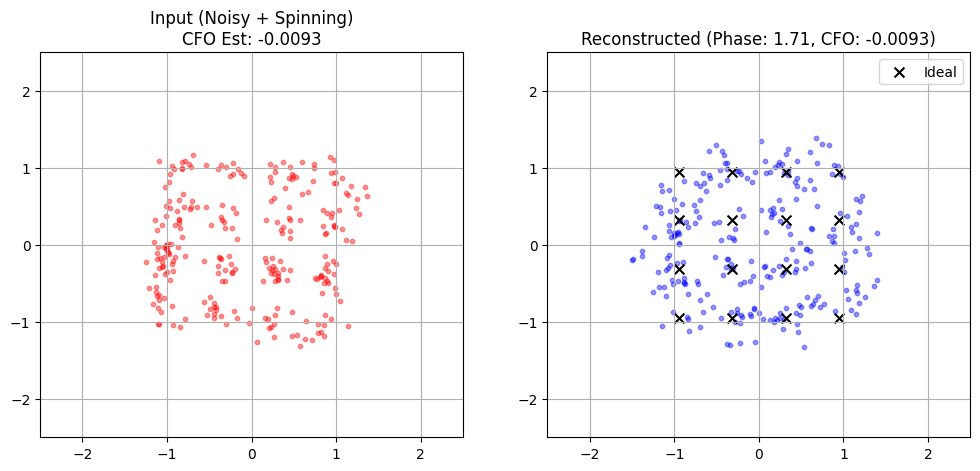

In [7]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, random_split
import torch
import random
from torch.utils.data import Subset


# -------------------------------------------------------------------------------------
# 1. Configuration & Hyperparameters
# -------------------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
EPOCHS = 100
LR = 0.001
SEQ_LEN = 256
N_PILOTS = 4         # Number of known symbols for phase locking
SNRS_DB = (5, 30)   # Training SNR range (dB)
SEED = 42

DATA_PATH = "./data/radio_divina_commedia.pth"

print(f"Using device: {DEVICE}")

# -------------------------------------------------------------------------------------
# 2. Helpers: 16-QAM & Utilities
# -------------------------------------------------------------------------------------
# Learn mapping from clean data to avoid any Gray-code or Endianness guesswork
def build_verified_constellation(path):
    ckpt = torch.load(path)
    iq_clean = ckpt['iq_clean'][0] 
    bits = ckpt['bits'][0]         
    z_clean = iq_clean[0] + 1j*iq_clean[1]
    
    b_reshaped = bits.reshape(-1, 4).long()
    # Packing: 8,4,2,1 matches the successful 'Nel mezzo' recovery
    indices = (b_reshaped[:,0]*8 + b_reshaped[:,1]*4 + b_reshaped[:,2]*2 + b_reshaped[:,3]*1)
    
    mapping = {}
    for i in range(len(indices)):
        idx = indices[i].item()
        if idx not in mapping:
            mapping[idx] = z_clean[i].item()
            
    return torch.tensor([mapping[i] for i in range(16)], dtype=torch.complex64, device=DEVICE)

CONST_TENSOR = build_verified_constellation(DATA_PATH)
CONST_POINTS = CONST_TENSOR.cpu().numpy()

def demap_16qam(iq_tensor):
    """
    Hard Slicing / Demodulation.
    Finds the nearest constellation point index (0-15).
    """
    # Distance metric: |x - c|^2
    # Shape: (B, T, 1) - (1, 1, 16) -> (B, T, 16)
    dist = torch.abs(iq_tensor.unsqueeze(-1) - CONST_TENSOR.unsqueeze(0).unsqueeze(0))
    return torch.argmin(dist, dim=-1)

def classical_pilot_estimate(noisy_pilots, clean_pilots):
    """
    Least-Squares Phase Estimation using Pilots.
    e^(j*theta) ~ sum(rx * conj(tx))
    """
    # noisy: (B, P) complex
    # clean: (B, P) complex
    phasor = (noisy_pilots * torch.conj(clean_pilots)).sum(dim=1)
    # Normalize to unit vector (cos, sin)
    phasor = phasor / (torch.abs(phasor) + 1e-8)
    return torch.stack([phasor.real, phasor.imag], dim=1).float()

# -------------------------------------------------------------------------------------
# 3. Dataset: Load Pre-Generated Dante Data (WITH CFO LABELS)
# -------------------------------------------------------------------------------------
def load_and_split_data(path, batch_size=BATCH_SIZE, seed=SEED):
    global SEQ_LEN # <--- FIX: Must be declared before use
    
    print(f"Loading and splitting dataset from {path}...")
    if not os.path.exists(path):
        raise FileNotFoundError(f"File {path} not found. Did you run the generator?")
        
    checkpoint = torch.load(path)
    
    x = checkpoint['iq_noisy'].float()
    y_phase = checkpoint['phase_labels'].float()
    y_cfo   = checkpoint['cfo_labels'].float() # <--- Load CFO
    bits    = checkpoint['bits'] 

    # Safety Check
    if x.shape[2] != SEQ_LEN:
        print(f"WARNING: Dataset length ({x.shape[2]}) != Config SEQ_LEN ({SEQ_LEN}). Adjusting config.")
        SEQ_LEN = x.shape[2]

    # --- ALIGNED BIT PACKING ---
    b_reshaped = bits.reshape(bits.shape[0], -1, 4).long()
    z = (b_reshaped[:,:,0]*8 + b_reshaped[:,:,1]*4 + b_reshaped[:,:,2]*2 + b_reshaped[:,:,3]*1)
    
    if y_phase.dim() > 1: y_phase = y_phase.squeeze()
    if y_cfo.dim() > 1:   y_cfo = y_cfo.squeeze()
    
    # ADD CFO TO DATASET: x, phase, cfo, symbols
    full_ds = TensorDataset(x, y_phase, y_cfo, z)
    
    # Split
    indices = list(range(len(full_ds)))
    random.Random(seed).shuffle(indices)
    
    train_end = int(0.75 * len(full_ds))
    val_end = train_end + int(0.20 * len(full_ds))
    
    train_ds = Subset(full_ds, indices[:train_end])
    val_ds = Subset(full_ds, indices[train_end:val_end])
    test_ds = Subset(full_ds, indices[val_end:])
    
    print(f"Split Summary: Train={len(train_ds)}, Val={len(val_ds)}, Test={len(test_ds)}")
    
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    )

train_loader, val_loader, test_loader = load_and_split_data(DATA_PATH)

# -------------------------------------------------------------------------------------
# 4. Network: Physics-Informed (Hybrid) Estimator
# -------------------------------------------------------------------------------------
class HybridPhaseNet(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, n_pilots=N_PILOTS):
        super().__init__()
        
        # Input Features: IQ (2*L) + Pilots (2*P) + Hint (2)
        input_dim = (2 * seq_len) + (2 * n_pilots) + 2
        
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            # OUTPUT LAYER: 3 Neurons
            # [0, 1] -> Cos, Sin for Phase
            # [2]    -> CFO (scalar)
            nn.Linear(128, 3) 
        )

    def forward(self, x, pilots, hint):
        x_flat = x.view(x.size(0), -1)
        p_flat = pilots.view(pilots.size(0), -1)
        combined = torch.cat([x_flat, p_flat, hint], dim=1)
        
        out = self.net(combined)
        
        # Split outputs
        # Phase vector (cos, sin) -> Angle
        phase_vec = out[:, :2] 
        phi_est = torch.atan2(phase_vec[:, 1], phase_vec[:, 0])
        
        # CFO (Raw scalar output)
        cfo_est = out[:, 2]
        
        return phi_est, cfo_est

# -------------------------------------------------------------------------------------
# 5. Training Loop (Tracks Phase MAE, CFO MAE, and Combined BER)
# -------------------------------------------------------------------------------------
# Check scaling
sample_x, _, _, _ = next(iter(train_loader)) 
print(f"Signal Power: {torch.mean(torch.abs(torch.complex(sample_x[:,0], sample_x[:,1]))**2):.4f}")

model = HybridPhaseNet().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)

# LOSSES
loss_phi = lambda p, t: 1.0 - torch.cos(p - t).mean() # Cosine distance for Phase
loss_cfo = nn.MSELoss()                               # MSE for CFO

# Time vector for reconstruction [0, 1, ..., L-1]
TIME_VEC = torch.arange(SEQ_LEN, device=DEVICE).float().unsqueeze(0) # [1, L]

print(f"--- Starting Hybrid Training ({EPOCHS} Epochs) ---")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    # Unpack 4 items: x, phase_label, cfo_label, symbols
    for x, y_phi, y_cfo, sym_ints in train_loader:
        x, y_phi, y_cfo = x.to(DEVICE), y_phi.to(DEVICE), y_cfo.to(DEVICE)
        sym_ints = sym_ints.to(DEVICE)
        
        # 1. Features
        pilot_idx = sym_ints[:, :N_PILOTS]
        pilot_ref = CONST_TENSOR[pilot_idx]
        x_c = torch.complex(x[:,0,:], x[:,1,:])
        
        hint = classical_pilot_estimate(x_c[:, :N_PILOTS], pilot_ref)
        p_feat = torch.stack([pilot_ref.real, pilot_ref.imag], dim=1).float()
        
        # 2. Forward
        phi_est, cfo_est = model(x, p_feat, hint)
        
        # 3. Combined Loss
        l_p = loss_phi(phi_est, y_phi)
        l_c = loss_cfo(cfo_est, y_cfo)
        # Weight CFO higher (100x) because it affects the whole sequence
        loss = l_p + (100.0 * l_c) 
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    
    # --- EVALUATION ---
    model.eval()
    val_phi_err = 0.0
    val_cfo_err = 0.0
    val_ber = 0.0
    total_syms = 0
    num_batches = len(val_loader)
    
    with torch.no_grad():
        for x, y_phi, y_cfo, sym_ints in val_loader:
            x, y_phi, y_cfo, sym_ints = x.to(DEVICE), y_phi.to(DEVICE), y_cfo.to(DEVICE), sym_ints.to(DEVICE)
            
            # Features
            pilot_idx = sym_ints[:, :N_PILOTS]
            pilot_ref = CONST_TENSOR[pilot_idx]
            x_c = torch.complex(x[:,0,:], x[:,1,:])
            hint = classical_pilot_estimate(x_c[:, :N_PILOTS], pilot_ref)
            p_feat = torch.stack([pilot_ref.real, pilot_ref.imag], dim=1).float()
            
            # Predict
            phi_est, cfo_est = model(x, p_feat, hint)
            
            # --- METRICS ---
            # 1. Phase MAE (Circular difference)
            diff = torch.atan2(torch.sin(phi_est - y_phi), torch.cos(phi_est - y_phi))
            val_phi_err += torch.abs(diff).sum().item()
            
            # 2. CFO MAE
            val_cfo_err += torch.abs(cfo_est - y_cfo).sum().item()
            
            # 3. Reconstruction (Using BOTH Phase + CFO)
            # Total Phase(t) = phi + (cfo * t)
            phase_ramp = phi_est.unsqueeze(1) + (cfo_est.unsqueeze(1) * TIME_VEC)
            
            # Apply Derotation
            correction = torch.exp(-1j * phase_ramp)
            rx_corrected = x_c * correction
            
            # Demap & BER
            est_idx = demap_16qam(rx_corrected)
            val_ber += (est_idx != sym_ints).sum().item()
            total_syms += sym_ints.numel()
            
    # Averages
    avg_phi_mae = val_phi_err / len(val_loader.dataset)
    avg_cfo_mae = val_cfo_err / len(val_loader.dataset)
    avg_ber = val_ber / total_syms
    
    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Phase MAE: {avg_phi_mae:.4f} | CFO MAE: {avg_cfo_mae:.6f} | BER: {avg_ber:.5f}")

# Save
MODEL_PATH = "./models/PhaseNet_hybrid.pth"
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model successfully saved to: {MODEL_PATH}")

# -------------------------------------------------------------------------------------
# 6. Final Visualization (Corrected for CFO)
# -------------------------------------------------------------------------------------

plt.figure(figsize=(12, 5))

# 1. Get one validation batch (NOW UNPACKING 4 ITEMS)
x, y_phi, y_cfo, sym_ints = next(iter(val_loader))
x, y_phi, y_cfo, sym_ints = x.to(DEVICE), y_phi.to(DEVICE), y_cfo.to(DEVICE), sym_ints.to(DEVICE)

# 2. Re-run inference
pilot_idx = sym_ints[:, :N_PILOTS]
pilot_ref = CONST_TENSOR[pilot_idx]
x_c = torch.complex(x[:,0,:], x[:,1,:])
hint = classical_pilot_estimate(x_c[:, :N_PILOTS], pilot_ref)
p_feat = torch.stack([pilot_ref.real, pilot_ref.imag], dim=1).float()

phi_est, cfo_est = model(x, p_feat, hint)

# 3. Select index 0 to plot
idx = 0

# --- RECONSTRUCTION LOGIC ---
# We must apply the time-varying rotation: exp(-j * (phi + cfo*t))
t_vec = torch.arange(SEQ_LEN, device=DEVICE).float()
phase_ramp = phi_est[idx] + (cfo_est[idx] * t_vec)
correction = torch.exp(-1j * phase_ramp)

rx_raw = x_c[idx].detach().cpu().numpy()
rx_clean = (x_c[idx] * correction).detach().cpu().numpy()

# 4. Plot
plt.subplot(1, 2, 1)
plt.scatter(rx_raw.real, rx_raw.imag, s=10, alpha=0.4, c='r')
plt.title(f"Input (Noisy + Spinning)\nCFO Est: {cfo_est[idx]:.4f}")
plt.grid(True); plt.xlim(-2.5, 2.5); plt.ylim(-2.5, 2.5)

plt.subplot(1, 2, 2)
plt.scatter(rx_clean.real, rx_clean.imag, s=10, alpha=0.4, c='b')
ideal = CONST_POINTS # Numpy array
plt.scatter(ideal.real, ideal.imag, s=50, marker='x', c='k', label='Ideal')
plt.title(f"Reconstructed (Phase: {phi_est[idx]:.2f}, CFO: {cfo_est[idx]:.4f})")
plt.grid(True); plt.xlim(-2.5, 2.5); plt.ylim(-2.5, 2.5)
plt.legend()

plt.show()

--- DIAGNOSTIC REPORT FOR ./data/radio_divina_commedia.pth ---
Data Shape: torch.Size([5140, 2, 256])

[CHECK 1] Bit Mapping & Clean BER
Found 16/16 Constellation points.
SUCCESS: Bit Mapping is consistent. Clean SER is 0.0000

[CHECK 2] Physics & CFO Labels
Sample 0:
  True Slope (Measured): 0.005246 rad/sample
  Label CFO            : 0.005173 rad/sample
  Diff                 : 0.000074
SUCCESS: Data physics matches labels.


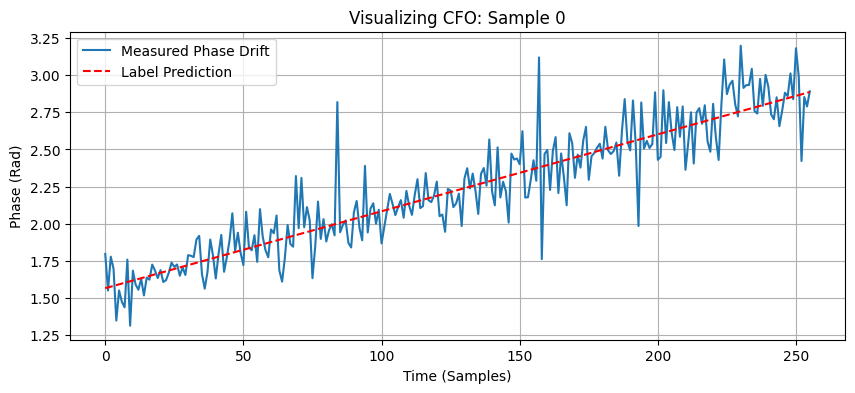

In [8]:
# =============================================================================
# DIAGNOSTIC CELL: CHECK DATA INTEGRITY & PHYSICS
# =============================================================================
import torch
import numpy as np
import matplotlib.pyplot as plt

# CONFIG
DATA_PATH = "./data/radio_divina_commedia.pth"
DEVICE = "cpu" # sufficient for diagnostics

def run_diagnostics():
    print(f"--- DIAGNOSTIC REPORT FOR {DATA_PATH} ---")
    
    # 1. LOAD FILE
    if not os.path.exists(DATA_PATH):
        print(f"ERROR: {DATA_PATH} not found.")
        return
        
    ckpt = torch.load(DATA_PATH, map_location=DEVICE)
    iq_noisy = ckpt['iq_noisy']  # [N, 2, L]
    iq_clean = ckpt['iq_clean']  # [N, 2, L]
    y_phase  = ckpt['phase_labels']
    y_cfo    = ckpt['cfo_labels']
    bits     = ckpt['bits']
    
    print(f"Data Shape: {iq_noisy.shape}")
    N, _, L = iq_noisy.shape
    
    # 2. CHECK BIT MAPPING (Crucial!)
    # We attempt to reconstruct the constellation from the first sample
    print("\n[CHECK 1] Bit Mapping & Clean BER")
    
    # Extract Complex IQ
    z_clean = torch.complex(iq_clean[:,0,:], iq_clean[:,1,:])
    
    # Reconstruct Integer Indices from Bits (Assumption: 8-4-2-1 Packing)
    b_reshaped = bits.reshape(N, -1, 4).long()
    z_indices_true = (b_reshaped[:,:,0]*8 + b_reshaped[:,:,1]*4 + b_reshaped[:,:,2]*2 + b_reshaped[:,:,3]*1)
    
    # Build Map: Index -> Complex Point
    # We iterate until we find all 16 points
    mapping = {}
    points_found = 0
    for i in range(N * L):
        batch_idx = i // L
        seq_idx = i % L
        idx_val = z_indices_true[batch_idx, seq_idx].item()
        c_val = z_clean[batch_idx, seq_idx].item()
        
        if idx_val not in mapping:
            mapping[idx_val] = c_val
            points_found += 1
        
        if points_found == 16:
            break
            
    print(f"Found {points_found}/16 Constellation points.")
    if points_found < 16:
        print("WARNING: Dataset too small or scrambled to find all 16 QAM points.")
        
    # Create Tensor for Demapping
    # Sort mapping by index 0..15
    const_list = [mapping.get(i, 0j) for i in range(16)]
    const_tensor = torch.tensor(const_list, device=DEVICE).view(1, 1, 16)
    
    # Test Demodulation on CLEAN data
    # distance |z - const|^2
    # z_clean: [N, L, 1]
    dist = torch.abs(z_clean.unsqueeze(-1) - const_tensor)
    z_indices_est = torch.argmin(dist, dim=-1) # [N, L]
    
    # Calc Clean BER (Symbol Error Rate actually)
    errors = (z_indices_est != z_indices_true).sum().item()
    total = z_indices_est.numel()
    clean_ser = errors / total
    
    if clean_ser == 0:
        print(f"SUCCESS: Bit Mapping is consistent. Clean SER is 0.0000")
    else:
        print(f"FAILURE: Clean SER is {clean_ser:.4f}. The 'bits' in file do not match 'iq_clean' via simple mapping.")
        print("POSSIBLE FIX: Check big-endian vs little-endian in text_to_bits.")

    # 3. CHECK PHYSICS (Slope = CFO?)
    print("\n[CHECK 2] Physics & CFO Labels")
    
    # Pick a random sample with High SNR (to visualize phase clearly)
    # or just sample 0
    idx = 0
    
    # Calculate Phase Difference between Noisy and Clean
    # noisy = clean * exp(j * theta(t))
    # => noisy / clean = exp(j * theta(t))
    # => theta(t) = angle(noisy / clean)
    z_n = torch.complex(iq_noisy[idx,0,:], iq_noisy[idx,1,:])
    z_c = z_clean[idx]
    
    # Rotation vector
    rot = z_n / z_c
    raw_angles = torch.angle(rot)
    
    # Unwrap to see the slope
    unwrapped = torch.from_numpy(np.unwrap(raw_angles.numpy()))
    
    # Linear Fit: y = mx + c
    t = torch.arange(L).float()
    # Simple Least Squares
    A = torch.vstack([t, torch.ones_like(t)]).T
    m, c = torch.linalg.lstsq(A, unwrapped).solution
    
    actual_cfo = m.item()
    actual_phi = c.item()
    
    label_cfo = y_cfo[idx].item()
    label_phi = y_phase[idx].item()
    
    print(f"Sample {idx}:")
    print(f"  True Slope (Measured): {actual_cfo:.6f} rad/sample")
    print(f"  Label CFO            : {label_cfo:.6f} rad/sample")
    print(f"  Diff                 : {abs(actual_cfo - label_cfo):.6f}")
    
    if abs(actual_cfo - label_cfo) > 1e-4:
         print("FAILURE: The Data rotation does not match the Label!")
         if abs(actual_cfo + label_cfo) < 1e-4:
             print("  -> ERROR IS SIGN FLIP. Label is positive, Data rotates negative (or vice versa).")
         elif abs(actual_cfo - 2*label_cfo) < 1e-4:
             print("  -> ERROR IS FACTOR OF 2.")
    else:
         print("SUCCESS: Data physics matches labels.")

    # PLOT
    plt.figure(figsize=(10, 4))
    plt.plot(t, unwrapped, label='Measured Phase Drift')
    plt.plot(t, label_cfo * t + label_phi, 'r--', label='Label Prediction')
    plt.title(f"Visualizing CFO: Sample {idx}")
    plt.xlabel("Time (Samples)")
    plt.ylabel("Phase (Rad)")
    plt.legend()
    plt.grid(True)
    plt.show()

run_diagnostics()